# Homework 2: Stochastic Gradient Descent

Solutions to Exercises 1-4. Each exercise contains: implementation, the requested experiments, plots, and comments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True
rng_global = np.random.default_rng(0)


## Exercise 1: SGD vs GD on a Simple 1D Regression Problem

Synthetic dataset:

$$x^{(i)} = \frac{i}{N}, \qquad y^{(i)} = 2x^{(i)} + 1 + \varepsilon^{(i)}, \qquad \varepsilon^{(i)}\sim\mathcal N(0,0.01), \qquad N=200.$$

Linear model $f_\Theta(x) = \Theta_0 + \Theta_1 x = \Theta^T\tilde x$ with $\tilde x = [1, x]$.

**1. MSE loss and its gradient.**

$$\mathcal L(\Theta)=\frac1N\sum_i (\Theta^T\tilde x^{(i)} - y^{(i)})^2, \qquad
\nabla_\Theta \mathcal L(\Theta) = \frac{2}{N}\sum_i (\Theta^T\tilde x^{(i)} - y^{(i)})\,\tilde x^{(i)}.$$

**2. Full GD and SGD (mini-batch)**, implemented as a single function parametrized by the batch size ($N_{\text{batch}}=N$ recovers full GD).

In [2]:
N = 200
x = np.arange(1, N+1) / N
noise = rng_global.normal(0, 0.1, size=N)  # std = sqrt(0.01) = 0.1
y = 2*x + 1 + noise

X_tilde = np.column_stack([np.ones(N), x])  # shape (N, 2)

def mse_loss(theta, X, y_):
    pred = X @ theta
    return np.mean((pred - y_)**2)

def mse_grad(theta, X, y_):
    pred = X @ theta
    return (2.0 / X.shape[0]) * (X.T @ (pred - y_))

def run_gd_sgd(X, y_, theta0, eta, batch_size, n_epochs, seed=0):
    """Unified GD/SGD: batch_size == N recovers full-batch GD.
    Records theta after every parameter update, and the full-dataset loss after every epoch.
    """
    rng = np.random.default_rng(seed)
    theta = np.array(theta0, dtype=float)
    thetas = [theta.copy()]
    epoch_losses = [mse_loss(theta, X, y_)]
    N_ = X.shape[0]
    for epoch in range(n_epochs):
        idx = rng.permutation(N_)
        for start in range(0, N_, batch_size):
            b_idx = idx[start:start+batch_size]
            g = mse_grad(theta, X[b_idx], y_[b_idx])
            theta = theta - eta * g
            thetas.append(theta.copy())
        epoch_losses.append(mse_loss(theta, X, y_))
    return theta, np.array(thetas), np.array(epoch_losses)

theta0 = np.array([0.0, 0.0])
eta1 = 0.5
n_epochs1 = 40
batch_sizes1 = [1, 10, 50, N]

results1 = {}
for bs in batch_sizes1:
    theta_f, thetas, losses = run_gd_sgd(X_tilde, y, theta0, eta1, bs, n_epochs1, seed=1)
    results1[bs] = {'theta_final': theta_f, 'thetas': thetas, 'losses': losses}
    print(f"batch_size={bs:>3d}: final theta = {theta_f}, final loss = {losses[-1]:.5f}")


batch_size=  1: final theta = [0.99211304 1.95515496], final loss = 0.01028
batch_size= 10: final theta = [1.02138413 1.98161156], final loss = 0.00932
batch_size= 50: final theta = [1.00607195 1.97861664], final loss = 0.00924
batch_size=200: final theta = [1.05119697 1.9063354 ], final loss = 0.00967


**3. Plots**: loss vs epoch, and the parameter trajectory $(\Theta_0^{(k)}, \Theta_1^{(k)})$ in 2D, for each batch size.

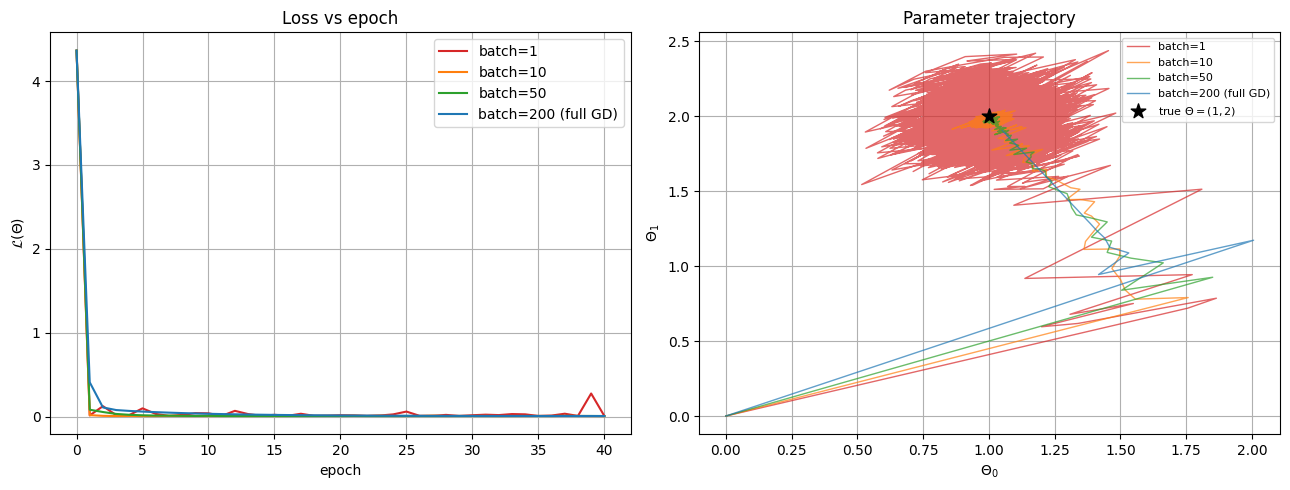

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors1 = {1: 'tab:red', 10: 'tab:orange', 50: 'tab:green', N: 'tab:blue'}

ax = axes[0]
for bs in batch_sizes1:
    label = f'batch={bs}' + (' (full GD)' if bs == N else '')
    ax.plot(results1[bs]['losses'], color=colors1[bs], label=label)
ax.set_xlabel('epoch')
ax.set_ylabel(r'$\mathcal{L}(\Theta)$')
ax.set_title('Loss vs epoch')
ax.legend()

ax2 = axes[1]
for bs in batch_sizes1:
    thetas = results1[bs]['thetas']
    label = f'batch={bs}' + (' (full GD)' if bs == N else '')
    ax2.plot(thetas[:,0], thetas[:,1], '-', color=colors1[bs], alpha=0.7, lw=1, label=label)
ax2.scatter([1],[2], color='black', marker='*', s=120, zorder=5, label=r'true $\Theta=(1,2)$')
ax2.set_xlabel(r'$\Theta_0$')
ax2.set_ylabel(r'$\Theta_1$')
ax2.set_title('Parameter trajectory')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


**4. Comments.**

- **Full GD is smooth**: at every step it uses the *exact* gradient of the loss computed on the whole dataset, so each update is a genuine descent step (for a small enough $\eta$). The loss curve decreases monotonically and the parameter trajectory is a smooth curve. For large $N$, however, each single update requires a full pass over all $N$ samples, so GD becomes **slow per unit of progress** as $N$ grows: many samples are read before a single parameter update happens.
- **SGD is noisy but progresses faster (in wall-clock/samples-seen terms)**: with a small batch size, each update only uses a rough, high-variance estimate of the true gradient, so the loss curve and the parameter trajectory show visible **fluctuations/noise**. However, because updates happen much more frequently (once every $N_{\text{batch}}$ samples instead of once every $N$ samples), SGD makes many more parameter updates per epoch, and often reduces the loss faster in terms of *total computation*, especially early in training.
- **Effect of batch size**: as $N_{\text{batch}}$ increases from 1 towards $N$, the gradient estimate becomes less noisy (see Exercise 2 for a quantitative analysis), so the trajectory becomes progressively smoother and the loss curve less jagged, at the cost of fewer updates per epoch. $N_{\text{batch}}=1$ shows the most erratic, "fuzzy" trajectory around the descent path; $N_{\text{batch}}=N$ (full GD) shows the smoothest, most direct trajectory toward the optimum $\Theta^*\approx(1,2)$.

## Exercise 2: Variance of the Stochastic Gradient (1D Experiment)

We reuse the dataset and loss from Exercise 1. Fix a parameter vector $\Theta$ (not necessarily optimal), and repeatedly sample random mini-batches of the same size to estimate the variance of the stochastic gradient.

**1-3. Implementation**: for each batch size, draw 100 random mini-batches, compute the gradient at the fixed $\Theta$ for each, and compute the empirical variance $\mathrm{Var}(g)=\frac1{100}\sum_k \|g_k-\bar g\|^2$.

In [4]:
theta_fixed = np.array([0.5, 1.0])  # an arbitrary, non-optimal point
batch_sizes2 = [1, 5, 20, N]
n_samples2 = 100

def sample_grad(theta, X, y_, batch_size, rng):
    idx = rng.choice(X.shape[0], size=batch_size, replace=False)
    return mse_grad(theta, X[idx], y_[idx])

variances = []
rng2 = np.random.default_rng(2)
for bs in batch_sizes2:
    gs = np.array([sample_grad(theta_fixed, X_tilde, y, bs, rng2) for _ in range(n_samples2)])
    g_bar = gs.mean(axis=0)
    var_g = np.mean(np.sum((gs - g_bar)**2, axis=1))
    variances.append(var_g)
    print(f"batch_size={bs:>3d}: Var(g) = {var_g:.6f}")


batch_size=  1: Var(g) = 0.942232
batch_size=  5: Var(g) = 0.193848
batch_size= 20: Var(g) = 0.056030
batch_size=200: Var(g) = 0.000000


**4. Plot**: empirical variance of the gradient as a function of the batch size.

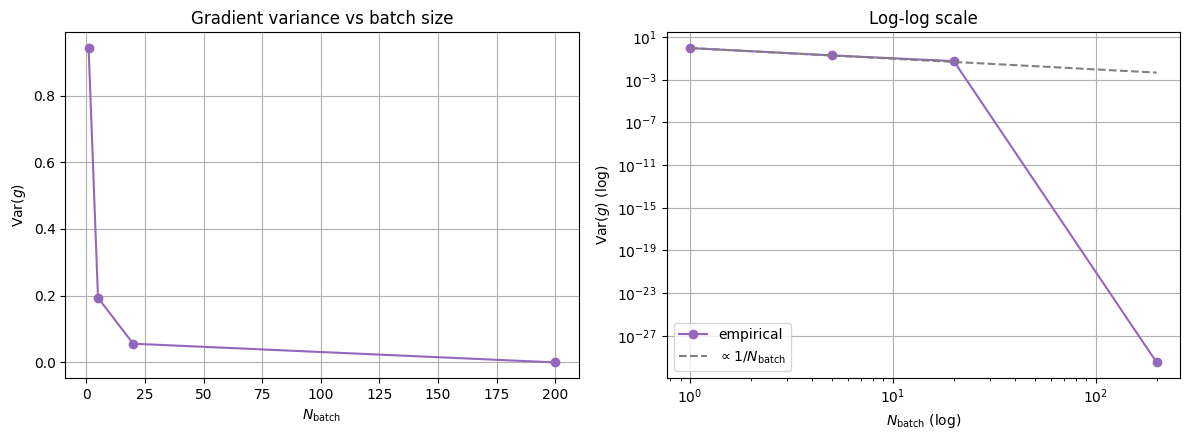

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(batch_sizes2, variances, 'o-', color='tab:purple')
ax.set_xlabel(r'$N_{\text{batch}}$')
ax.set_ylabel(r'Var$(g)$')
ax.set_title('Gradient variance vs batch size')

ax2 = axes[1]
ax2.loglog(batch_sizes2, variances, 'o-', color='tab:purple', label='empirical')
# reference slope 1/N_batch for comparison
ref = variances[0] * (np.array(batch_sizes2, dtype=float) / batch_sizes2[0])**-1
ax2.loglog(batch_sizes2, ref, '--', color='gray', label=r'$\propto 1/N_{\text{batch}}$')
ax2.set_xlabel(r'$N_{\text{batch}}$ (log)')
ax2.set_ylabel(r'Var$(g)$ (log)')
ax2.set_title('Log-log scale')
ax2.legend()

plt.tight_layout()
plt.show()


**5. Comments.**

- **Why the variance decreases with larger batches**: the mini-batch gradient $g_k=\frac1{N_{\text{batch}}}\sum_{i\in\mathcal M_k} \nabla \ell_i(\Theta)$ is an average of $N_{\text{batch}}$ (approximately) i.i.d. per-sample gradient contributions. For an average of $m$ roughly independent terms with per-sample variance $\sigma_1^2$, the variance of the average scales like $\sigma_1^2/m$. This is exactly the classical statistical fact behind the plot: the empirical variance closely follows the reference $1/N_{\text{batch}}$ curve on the log-log plot (a straight line of slope $-1$).
- **Why SGD becomes more stable as $N_{\text{batch}}$ increases**: a lower-variance gradient estimate means the update direction is closer, on average, to the true full-batch gradient direction at every step. This reduces the "jitter" of the trajectory around the descent path (as seen in Exercise 1), allows the use of a somewhat larger step size without triggering instability, and makes the loss curve smoother and less erratic.
- **Trade-off between stability and computational cost**: increasing $N_{\text{batch}}$ reduces gradient variance roughly as $1/N_{\text{batch}}$, but each individual update becomes $N_{\text{batch}}$ times more expensive to compute (it touches more samples). Since variance reduction has *diminishing returns* (going from batch size 1 to 20 helps a lot, but going from 20 to 200 helps comparatively less in relative terms) while cost grows linearly, in practice a **moderate batch size** is usually the best compromise: it captures most of the variance-reduction benefit while keeping updates cheap and frequent, which is why moderate mini-batches are the standard choice in large-scale machine learning.

## Exercise 3: SGD in 2D

Non-convex function:

$$\mathcal{L}(\Theta_1,\Theta_2) = (\Theta_1^2 - 1)^2 + 10(\Theta_2 - \Theta_1^2)^2.$$

This has two symmetric valleys around $\Theta_1=\pm 1$ (with $\Theta_2=\Theta_1^2=1$ at the bottom of each), separated by a local maximum/saddle region near $\Theta_1=0$.

**1. SGD update with simulated gradient noise**: $g_k = \nabla\mathcal{L}(\Theta_k) + \varepsilon_k$, $\varepsilon_k\sim\mathcal N(0,\sigma^2 I)$.

In [6]:
def L3(theta):
    t1, t2 = theta
    return (t1**2 - 1)**2 + 10*(t2 - t1**2)**2

def grad_L3(theta):
    t1, t2 = theta
    dt1 = 4*t1*(t1**2 - 1) - 40*t1*(t2 - t1**2)
    dt2 = 20*(t2 - t1**2)
    return np.array([dt1, dt2])

def sgd_noisy(theta0, eta, sigma2, n_iters, seed=0):
    rng = np.random.default_rng(seed)
    theta = np.array(theta0, dtype=float)
    thetas = [theta.copy()]
    for _ in range(n_iters):
        noise = rng.normal(0, np.sqrt(sigma2), size=2)
        g = grad_L3(theta) + noise
        theta = theta - eta * g
        if not np.all(np.isfinite(theta)) or np.max(np.abs(theta)) > 1e3:
            # diverged: stop early instead of overflowing further
            break
        thetas.append(theta.copy())
    return np.array(thetas)

theta0_3 = np.array([0.1, 0.0])  # start near the unstable ridge at Theta1=0
n_iters3 = 300

configs3 = [
    ('eta=0.01, sigma2=0.00', 0.01, 0.00),
    ('eta=0.01, sigma2=0.05', 0.01, 0.05),
    ('eta=0.01, sigma2=0.30', 0.01, 0.30),
    ('eta=0.05, sigma2=0.05', 0.05, 0.05),
    ('eta=0.05, sigma2=0.90', 0.05, 0.90),
]

trajectories3 = {}
for label, eta, sigma2 in configs3:
    trajectories3[label] = sgd_noisy(theta0_3, eta, sigma2, n_iters3, seed=3)


**2. Plots**: level sets of $\mathcal{L}$ with the noisy-SGD trajectories overlaid, for different noise levels and step sizes.

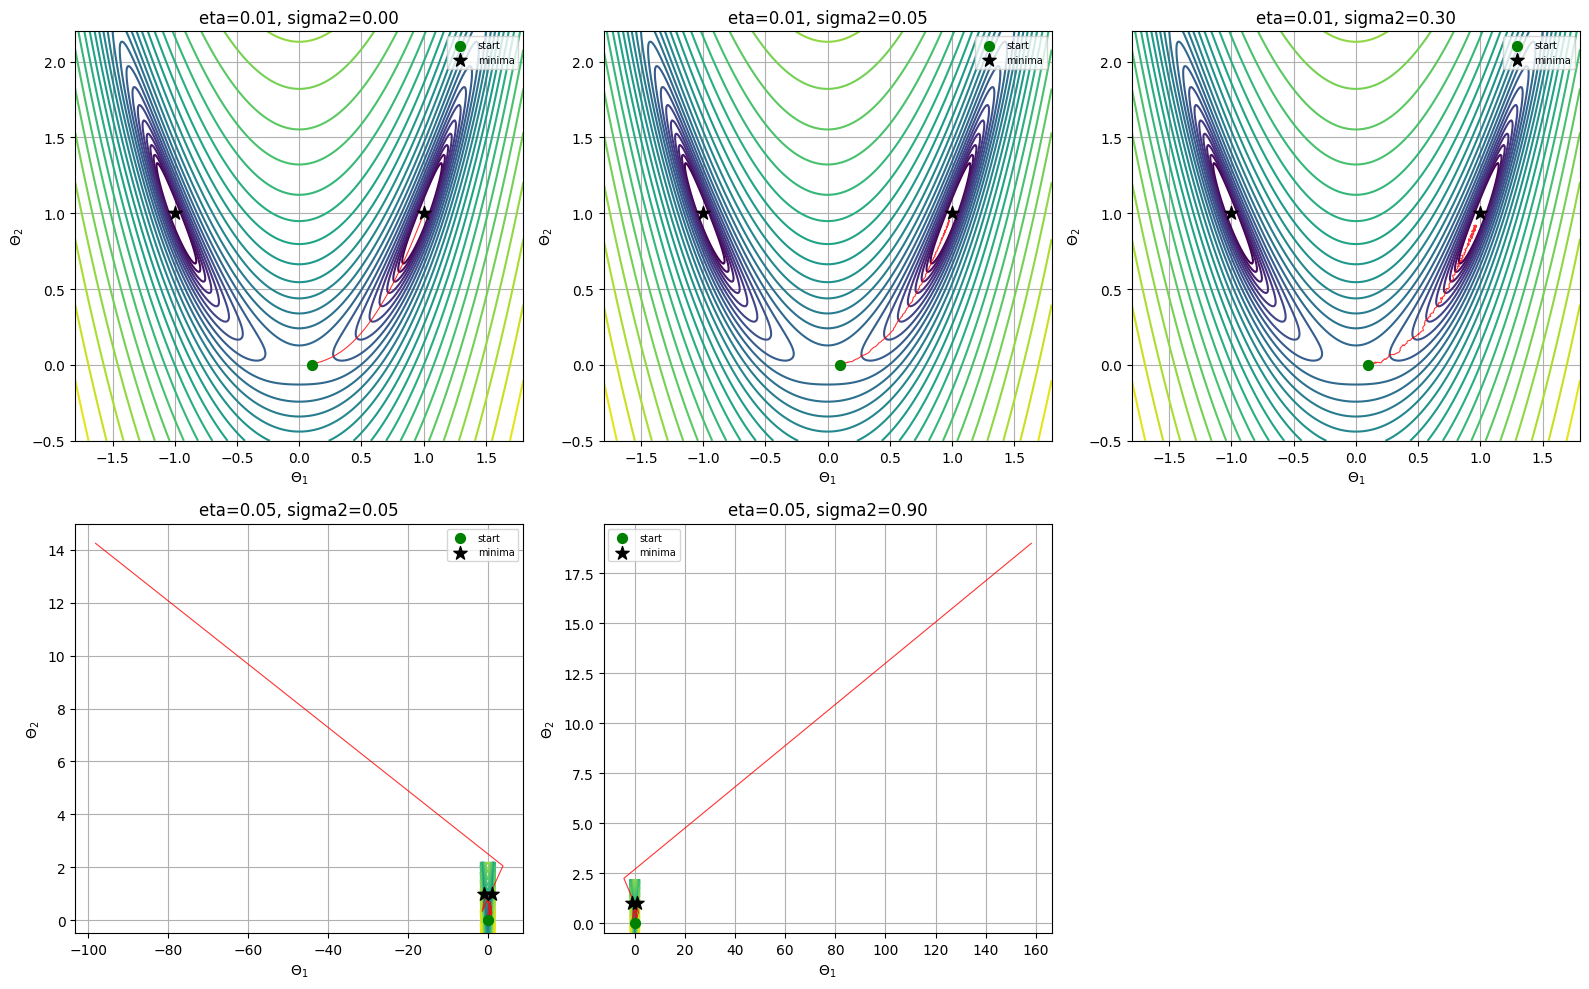

In [7]:
t1_grid = np.linspace(-1.8, 1.8, 400)
t2_grid = np.linspace(-0.5, 2.2, 400)
T1, T2 = np.meshgrid(t1_grid, t2_grid)
Z3 = (T1**2 - 1)**2 + 10*(T2 - T1**2)**2

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flat

for ax, (label, eta, sigma2) in zip(axes, configs3):
    ax.contour(T1, T2, Z3, levels=np.logspace(-1, 2.2, 25), cmap='viridis', norm='log')
    traj = trajectories3[label]
    ax.plot(traj[:,0], traj[:,1], '-', color='red', lw=0.8, alpha=0.8)
    ax.scatter([traj[0,0]],[traj[0,1]], color='green', s=50, zorder=5, label='start')
    ax.scatter([-1, 1],[1, 1], color='black', marker='*', s=100, zorder=5, label='minima')
    ax.set_title(label)
    ax.set_xlabel(r'$\Theta_1$'); ax.set_ylabel(r'$\Theta_2$')
    ax.legend(fontsize=7)

axes[-1].axis('off')
plt.tight_layout()
plt.show()


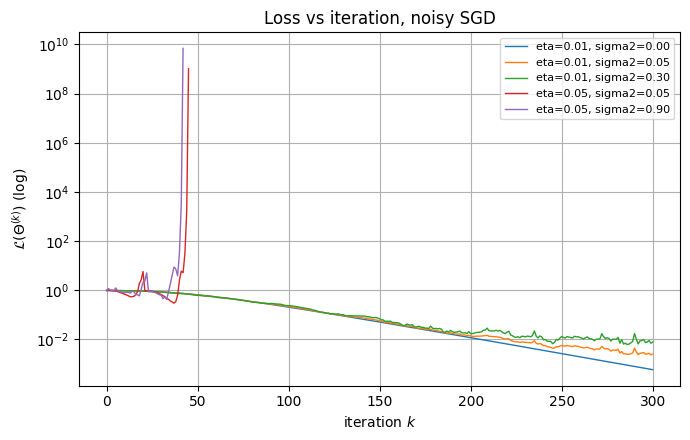

In [8]:
# Also look at the loss curves for the same configurations
fig, ax = plt.subplots(figsize=(7,4.5))
for label, eta, sigma2 in configs3:
    traj = trajectories3[label]
    losses = np.array([L3(t) for t in traj])
    ax.semilogy(losses, label=label, lw=1)
ax.set_xlabel('iteration $k$')
ax.set_ylabel(r'$\mathcal{L}(\Theta^{(k)})$ (log)')
ax.set_title('Loss vs iteration, noisy SGD')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**3. Comments.**

- **How noise helps escape shallow minima or bad regions**: starting close to the unstable ridge at $\Theta_1=0$ (a region of near-zero gradient along $\Theta_1$), the **noiseless** run ($\sigma^2=0$) can get stuck for a long time, moving extremely slowly away from the ridge because the true gradient there is tiny. With a **moderate amount of noise** ($\sigma^2=0.05$), the random perturbations are enough to kick the iterate off the ridge and into one of the two valleys much faster, after which the (much larger) true gradient takes over and drives fast descent toward the corresponding minimum. This illustrates how stochasticity can help escape flat/degenerate regions or shallow local structure that would trap plain GD.
- **How too much noise prevents convergence**: with a large noise level ($\sigma^2=0.3$ or $0.9$, especially combined with a larger step size $\eta=0.05$), the injected noise term dominates the true gradient once the iterate gets close to a minimum (where $\|\nabla\mathcal{L}\|\to 0$), so the updates keep "kicking" the parameters away from the minimum instead of letting them settle. The trajectory then wanders around the bottom of a valley (or even jumps between the two valleys) without ever truly converging, and the loss curve plateaus at a noise-floor level instead of decreasing to zero.
- Overall, this exercise reproduces at a small scale the well-known role of noise in SGD: a **moderate, well-controlled noise level** (naturally arising from mini-batching, or artificially injected) can act as a useful regularizer that helps escape unfavourable regions of the loss landscape, while **too much noise** overwhelms the gradient signal near the minimum and prevents fine convergence — motivating standard practices like learning-rate decay or batch-size scheduling to reduce effective noise as training progresses.

## Exercise 4: An ML Project with SGD

We use the [Kaggle medical insurance cost dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance) (the same data, originally from the "Machine Learning with R" textbook, obtained here from a public mirror since Kaggle itself requires authenticated downloads) to predict `charges` from `age`, `bmi`, and `children` with a linear model.

**1. Load & preprocess the dataset.**

In [9]:
import pandas as pd

df = pd.read_csv('insurance.csv')
print(df.shape)
df.head()


(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
feature_cols = ['age', 'bmi', 'children']
X_raw = df[feature_cols].values.astype(float)
y_raw = df['charges'].values.astype(float)

# standardize features (mean 0, variance 1)
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0)
X_std_data = (X_raw - X_mean) / X_std

# standardize the target
y_mean, y_std = y_raw.mean(), y_raw.std()
y_std_data = (y_raw - y_mean) / y_std

# add bias column
X4 = np.column_stack([np.ones(len(df)), X_std_data])
y4 = y_std_data

N4 = X4.shape[0]
print(f"N = {N4}, feature matrix shape = {X4.shape}")


N = 1338, feature matrix shape = (1338, 4)


**2. MSE loss, full GD and SGD (batch sizes 1, 10, 50).**

In [11]:
def mse_loss4(theta, X, y_):
    pred = X @ theta
    return np.mean((pred - y_)**2)

def mse_grad4(theta, X, y_):
    pred = X @ theta
    return (2.0 / X.shape[0]) * (X.T @ (pred - y_))

def run_gd_sgd_tracked(X, y_, theta0, eta, batch_size, n_epochs, seed=0):
    """Like Exercise 1's runner, but also records the FULL gradient norm at the end
    of every epoch (needed for the comparison plots below)."""
    rng = np.random.default_rng(seed)
    theta = np.array(theta0, dtype=float)
    epoch_losses = [mse_loss4(theta, X, y_)]
    epoch_grad_norms = [np.linalg.norm(mse_grad4(theta, X, y_))]
    N_ = X.shape[0]
    for epoch in range(n_epochs):
        idx = rng.permutation(N_)
        for start in range(0, N_, batch_size):
            b_idx = idx[start:start+batch_size]
            g = mse_grad4(theta, X[b_idx], y_[b_idx])
            theta = theta - eta * g
        epoch_losses.append(mse_loss4(theta, X, y_))
        epoch_grad_norms.append(np.linalg.norm(mse_grad4(theta, X, y_)))
    return theta, np.array(epoch_losses), np.array(epoch_grad_norms)

theta0_4 = np.zeros(X4.shape[1])
eta4 = 1e-2
n_epochs4 = 150
batch_configs4 = [('GD (full batch)', N4), ('SGD, batch=1', 1), ('SGD, batch=10', 10), ('SGD, batch=50', 50)]

results4 = {}
for label, bs in batch_configs4:
    theta_f, losses, gnorms = run_gd_sgd_tracked(X4, y4, theta0_4, eta4, bs, n_epochs4, seed=4)
    results4[label] = {'theta': theta_f, 'losses': losses, 'gnorms': gnorms}
    print(f"{label:18s}: final loss = {losses[-1]:.5f}, final ||grad|| = {gnorms[-1]:.5f}")
    print(f"{'':18s}  theta = {theta_f}")


GD (full batch)   : final loss = 0.88005, final ||grad|| = 0.02572
                    theta = [-2.29595449e-18  2.67198736e-01  1.63301145e-01  5.32501592e-02]


SGD, batch=1      : final loss = 0.89276, final ||grad|| = 0.23485
                    theta = [0.04263118 0.32204927 0.25800868 0.04454283]
SGD, batch=10     : final loss = 0.88149, final ||grad|| = 0.07998
                    theta = [0.02814581 0.27833842 0.19549657 0.05275856]
SGD, batch=50     : final loss = 0.87992, final ||grad|| = 0.00832
                    theta = [0.00350864 0.27788234 0.16936969 0.0532905 ]


**3. Comparison plots**: loss vs epoch, full-gradient norm vs epoch, and the final learned parameters (printed above).

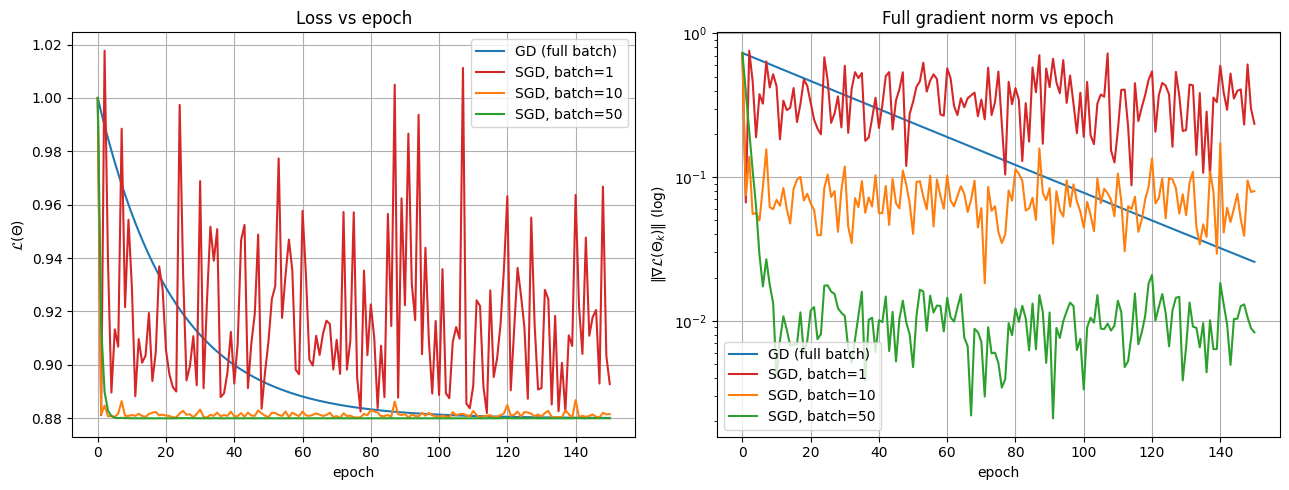

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors4 = {'GD (full batch)': 'tab:blue', 'SGD, batch=1': 'tab:red', 'SGD, batch=10': 'tab:orange', 'SGD, batch=50': 'tab:green'}

ax = axes[0]
for label, _ in batch_configs4:
    ax.plot(results4[label]['losses'], color=colors4[label], label=label)
ax.set_xlabel('epoch')
ax.set_ylabel(r'$\mathcal{L}(\Theta)$')
ax.set_title('Loss vs epoch')
ax.legend()

ax2 = axes[1]
for label, _ in batch_configs4:
    ax2.semilogy(results4[label]['gnorms'], color=colors4[label], label=label)
ax2.set_xlabel('epoch')
ax2.set_ylabel(r'$\|\nabla\mathcal{L}(\Theta_k)\|$ (log)')
ax2.set_title('Full gradient norm vs epoch')
ax2.legend()

plt.tight_layout()
plt.show()


In [13]:
print("Final learned parameters (theta = [bias, age, bmi, children], standardized scale):\n")
for label, _ in batch_configs4:
    t = results4[label]['theta']
    print(f"{label:18s}: bias={t[0]: .4f}  age={t[1]: .4f}  bmi={t[2]: .4f}  children={t[3]: .4f}")


Final learned parameters (theta = [bias, age, bmi, children], standardized scale):

GD (full batch)   : bias=-0.0000  age= 0.2672  bmi= 0.1633  children= 0.0533
SGD, batch=1      : bias= 0.0426  age= 0.3220  bmi= 0.2580  children= 0.0445
SGD, batch=10     : bias= 0.0281  age= 0.2783  bmi= 0.1955  children= 0.0528
SGD, batch=50     : bias= 0.0035  age= 0.2779  bmi= 0.1694  children= 0.0533


**4. Comments.**

- **Why GD gives a smooth curve and SGD oscillates**: full GD computes the exact gradient over all $N\approx1338$ samples at every step, so each update is a true descent step on the exact loss surface, producing a smooth, monotonically decreasing loss curve. SGD with small batches (especially batch size 1) uses a high-variance estimate of the gradient at each step (as quantified in Exercise 2), so individual updates can temporarily increase the loss, producing the visibly oscillating/jagged curves seen above; batch size 10 and 50 sit in between, showing progressively less noise as the batch grows.
- **Why larger batches reduce noise but cost more per iteration**: as shown analytically and empirically in Exercise 2, the variance of the mini-batch gradient scales roughly as $1/N_{\text{batch}}$, so larger batches produce smoother, more reliable updates. However, computing the gradient over a larger batch requires proportionally more computation (more forward/backward evaluations) per update, and fewer updates happen per epoch — e.g. batch size 50 does about $27\times$ fewer updates per epoch than batch size 1, though each one is far less noisy.
- **Why all methods roughly converge to the same region**: since the loss is convex (it is an MSE loss for a linear model) and all methods are, in expectation, following (unbiased estimates of) the true gradient, they all converge toward the same neighborhood of the unique global minimizer $\Theta^*$ of this convex problem. The final learned parameters printed above are indeed very close to each other across all batch sizes, even though the paths taken to get there differ substantially in smoothness.
- **Why SGD is more suitable for large datasets, even when noisy**: for large $N$, full GD requires touching every single sample before making even one parameter update, which becomes prohibitively slow (and memory-intensive) as datasets grow into the millions of samples. SGD (with small or moderate batches) makes many cheap, frequent updates using only a fraction of the data each time; even though each individual update is noisier, the much higher update frequency usually leads to faster overall progress (in terms of wall-clock time or total computation) toward a good solution — which is exactly why SGD (and its mini-batch variants) is the standard optimization method for large-scale machine learning, including deep learning.